# HW2: Local Planning

### EECE 5550: Mobile Robotics (Spring 2024)


**Collaboration Statement:**

In [17]:
# Fill this in per the syllabus, or we will assign a zero to this assignment.
"""
Name : Abhishek Uddaraju
Collaboration Statement: The assignment is done independetly without collaboration.
"""

'\nName : Abhishek Uddaraju\nCollaboration Statement: The assignment is done independetly without collaboration.\n'

# Installation

This semester, we will use a custom simulator, called `gym-neu-racing`, to develop navigation algorithms. We implemented the basic structure of this simulator for you, and the HW assignments will ask you to implement important functions (e.g., kinematics, sensing, planning, mapping).

To install the simulator, you can use this command (it will download the latest code from GitLab and automatically install it in the environment your Colab notebook runs in):

In [18]:
#!pip install git+https://gitlab.com/neu-autonomy/gym-neu-racing.git

Now that the simulator and its dependencies have been installed, you can import the modules you'll need for this assignment:

In [4]:
import gymnasium
import numpy as np
import gym_neu_racing
from gymnasium import spaces
from gym_neu_racing.envs.wrappers import StateFeedbackWrapper
import matplotlib.pyplot as plt
from typing import Callable
import matplotlib.cm as cmx
import matplotlib.colors as colors
from gym_neu_racing import motion_models
from IPython.display import clear_output
import cv2

# Problem 1: MPPI

## 1a) MPPI to move toward a goal coordinate

In this problem, you'll implement a basic version of MPPI and show that it outputs a good rollout to move a robot toward a given goal position. This part uses the Unicycle kinematic model that's built into the simulator. You should  make sure that your `get_action` method considers the control limits (otherwise it may command things that the robot can't execute), which may require passing those as arguments to the `__init__` method.

You will probably need to experiment with different numbers of rollouts, cost functions, λ values, numbers of iterations, etc. to get good performance.

Keeping this code relatively organized and clean will help for later parts in the assignment, where you build on this implementation. For example, you are encouraged to define helper methods in your `MPPI` class to help keep your code organized (e.g., you may want a `score_rollouts` and/or `plot_rollouts` method that get called inside the `get_next_action` method).

**Deliverables**:
- Implement the `MPPI` class, in particular the `get_next_action` method, so that the chosen rollout drives the robot toward the goal position.
- Print the best control sequence your MPPI algorithm came up with (the first row/element of this sequence should be the action that your `get_action` returns)
- Include a plot that shows the rollouts, start position, goal position, and highlights the best rollout in that iteration, for at least a few iterations. We expect that the later iterations will give much better rollouts than the first iteration. You should make your axes have the same scale (e.g., using `plt.axis('equal')`).

In [5]:
# Create an instance of the mobile robot simulator we'll use this semester
env = gymnasium.make("gym_neu_racing/NEUEmptyWorld-v0")

# Tell the simulator to directly provide the current state vector (no sensors yet)
env = StateFeedbackWrapper(env)

In [6]:
class MPPI:
    def __init__(
        self,
        motion_model = motion_models.Unicycle(),
        v_min=0, v_max=1, w_min=-2*np.pi, w_max=2*np.pi,
        num_rollouts = 50,  ##????
        num_steps = 10, ##????
        lamda = 1

    ):
        """ Your implementation here """
        self.motion_model = motion_model
        self.action_space = spaces.Box(np.array([v_min, w_min]),
                                       np.array([v_max, w_max]), shape=(2,), dtype=float)
        self.num_rollouts = num_rollouts
        self.num_steps = num_steps
        self.perturbations = None
        self.lamda = lamda

    def generate_perturbations(self):
      '''
      Generates pertubations by randomly sampling form normal distrabution
      i/p : self
      o/p : np.ndarray of shape (self.num_rollouts,self.num_steps,2)
      '''
      V_samples = np.random.normal(0, 0.1, size=(self.num_rollouts, self.num_steps))
      V_scaled_samples = np.clip(V_samples, -1, 1)
      dv = V_scaled_samples
      W_samples = np.random.normal(0, 0.3, size=(self.num_rollouts, self.num_steps))
      W_scaled_samples = np.clip(W_samples, -1, 1)
      dw = W_scaled_samples * 2 * np.pi
      perturbations = []
      for n in range(self.num_rollouts):
        du_N = []
        for t in range(self.num_steps):
          du_N.append([dv[n,t], dw[n,t]])
        perturbations.append(du_N)

      self.perturbations = np.array(perturbations)

      # Plotting histograms of samples
      perturbations = np.array(self.perturbations)
      fig, axes = plt.subplots(1, 2, figsize=(12, 5))
      # Titles for the histograms
      titles = ['Linear Velocity', 'Angular Velocity']
      for i, ax in enumerate(axes):
          ax.hist(perturbations[:, :, i].reshape(-1), bins=50, density=True, alpha=0.6, color='b' if i == 0 else 'r')
          ax.set_title(f'Perturbation {titles[i]} samples')
          ax.set_xlabel('Value')
          ax.set_ylabel('Frequency')
          ax.grid(True)
      plt.show()
      print("shape of perturbations:", np.shape(self.perturbations))

    def open_loop_control_policy(self, init_state: np.ndarray, goal: np.ndarray, num_steps: int = 10) -> list[np.ndarray]:
      # The goal state is in global frame so we need to convert it to robot farame
      initial_x = init_state[0]
      initial_y = init_state[1]
      initial_theta = init_state[2]
      rotation_mat = [[ np.cos(initial_theta), np.sin(initial_theta)] ,
                      [-1 * np.sin(initial_theta), np.cos(initial_theta)]]
      g = goal.tolist()
      dif_initial_g = [g[0] - initial_x, g[1] - initial_y]
      x_relative , y_relative = np.matmul(rotation_mat, dif_initial_g)

      len_squ = (x_relative)**2 + (y_relative)**2

      # lets consider tangential velocity 1m/s
      v = 0.9
      if y_relative==0:
        w = 0.0001
      else:
        r =  len_squ / (2* y_relative)
        w =  v / r
      control_sequence = []
      for i in range(num_steps):
        control_sequence.append(np.array([v,w]))
      return np.array(control_sequence)

    def simulting_action_seq(self, initial_state: np.ndarray, NxT_control_sequences):
      N, T, _ = NxT_control_sequences.shape
      NxTplus1_states = []
      for n in range(N):
        Tplus1_states = []
        state = initial_state
        Tplus1_states.append(state)
        for t in range(T):
          state = self.motion_model.step(state, NxT_control_sequences[n,t])
          Tplus1_states.append(state)
        NxTplus1_states.append(Tplus1_states)
      NxTplus1_states = np.array(NxTplus1_states)
      return NxTplus1_states

    def plot_rollouts(self, initial_state: np.ndarray, goal_pos: np.ndarray, NxTplus1_states):
      # Plotting each rollout
      N, T_plus_1, _ = NxTplus1_states.shape
      for i in range(N):
          rollout = NxTplus1_states[i]
          x_positions = rollout[:, 0]
          y_positions = rollout[:, 1]
          plt.plot(x_positions, y_positions, marker='o', label=f'Rollout {i+1}', alpha = 0.3)
      plt.scatter(initial_state[0], initial_state[1], color='green', marker='o', label='Initial State')
      plt.scatter(goal_pos[0], goal_pos[1], color='red', marker='x', label='Goal Position')
      # Adding labels and legend
      plt.title('Position of Robot in Each Rollout')
      plt.xlabel('X Position')
      plt.ylabel('Y Position')
      plt.axis('equal')
      plt.grid(True)
      plt.show()

    def calculate_distance(self,point1, point2):
        x1, y1 = point1
        x2, y2 = point2
        distance = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
        return distance

    def score_rollouts(self,initial_state: np.ndarray, goal_pos: np.ndarray, NxTplus1_states: np.ndarray):
      """
      Cost is calculated by calculating distance between the intermediat states to the goal state

      Returns: Normalized costs of each rollout
      """

      N, T_plus_1, _ = NxTplus1_states.shape
      D = self.calculate_distance(initial_state[:-1], goal_pos) #Distance form initial state to goal
      N_costs = []
      for n in range(N):
        cost = 0
        reached_goal = False
        hit_wall = False
        for t in range(T_plus_1):
          if hit_wall:
            cost += 100
          elif reached_goal:
            cost += 0
          else:
            x = NxTplus1_states[n,t][0]
            y = NxTplus1_states[n,t][1]
            d = self.calculate_distance([x,y], goal_pos)

            # if -0.2<= x <=0.5 and 0.2<= y <= 0.4:
            #   hit_wall = True

            #print("hit_wall :", hit_wall)
            if hit_wall:
              cost += 1000
            elif d<=0.1:
              reached_goal = True
              cost += 0
            else:
              cost += d
        total_cost = cost/(self.num_steps)
        N_costs.append(total_cost)
      N_costs = np.array(N_costs)
      return N_costs

    def get_action(self, initial_state: np.ndarray, goal_pos: np.ndarray):
        """ Your implementation here """
        ## Step 1 : Creating the random samples of N control perturbations seqences
        if self.perturbations == None:
          self.generate_perturbations()


        ## Step 2 : Pass control Sequences throught dynamic model
        # 2.1 : Generating primaray control using open loop control
        u_dash = self.open_loop_control_policy(init_state=initial_state, goal = goal_pos, num_steps= self.num_steps)

        # 2.2 : Adding perturbations and creating N control sequences
        NxT_control_sequences = np.copy(self.perturbations)
        for n in range(self.num_rollouts):
          for t in range(self.num_steps):
            NxT_control_sequences[n,t,0] = u_dash[t,0] + NxT_control_sequences[n,t,0]
            NxT_control_sequences[n,t,1] = u_dash[t,1] + NxT_control_sequences[n,t,1]

        # 2.3 : passing throught kinematics model
        """initial_state sequence_of_actions >> kinematics model >> states at each steps """
        NxTplus1_states = self.simulting_action_seq(initial_state, NxT_control_sequences)

        # 2.4 : Plotting Rollouts
        self.plot_rollouts(initial_state, goal_pos, NxTplus1_states)

        ## Step 3 : Scorring Rollouts
        """ states of each rollout at each step >> cost functin >> score of rollout """
        N_costs = self.score_rollouts(initial_state, goal_pos, NxTplus1_states)

        ## Step 4 : Updating weighted sum only for the initial step
        # 4.1 : Calcualting Weights
        exp_costs = np.exp(-1*N_costs/self.lamda)
        sum_exp_costs = np.sum(exp_costs)
        print(exp_costs)
        N_weights = exp_costs/sum_exp_costs


        # 4.2 : Updating the initial control sequence
        NxT_perturbations = self.perturbations
        updated_u_dash = np.copy(u_dash)
        for t in range(self.num_steps):
          dv = 0
          dw = 0
          for n in range(self.num_rollouts):
            dv += NxT_perturbations[n,t][0] * N_weights[n]
            dw += NxT_perturbations[n,t][1] * N_weights[n]
          updated_u_dash[t][0] = updated_u_dash[t][0] + dv
          updated_u_dash[t][1] = updated_u_dash[t][1] + dw

        # checking the control limits
        updated_u_dash[:,0] = np.clip(updated_u_dash[:,0], -1, 1)
        updated_u_dash[:,1] = np.clip(updated_u_dash[:,1], -2*np.pi, 2*np.pi)

        # 4.3 Plot the updated trajectory
        # passing through simulatior or kinematics model
        NxTplus1_states = self.simulting_action_seq(initial_state, np.expand_dims(updated_u_dash, axis=0))
        self.plot_rollouts(initial_state, goal_pos, NxTplus1_states)

        print(updated_u_dash)
        print(u_dash)

        return updated_u_dash[0]

You can use the following code to check whether your MPPI implementation is working. After tuning your algorithm, it should be able to come up with a rollout that ends close to the goal (within 0.1m in l2 distance is close enough):

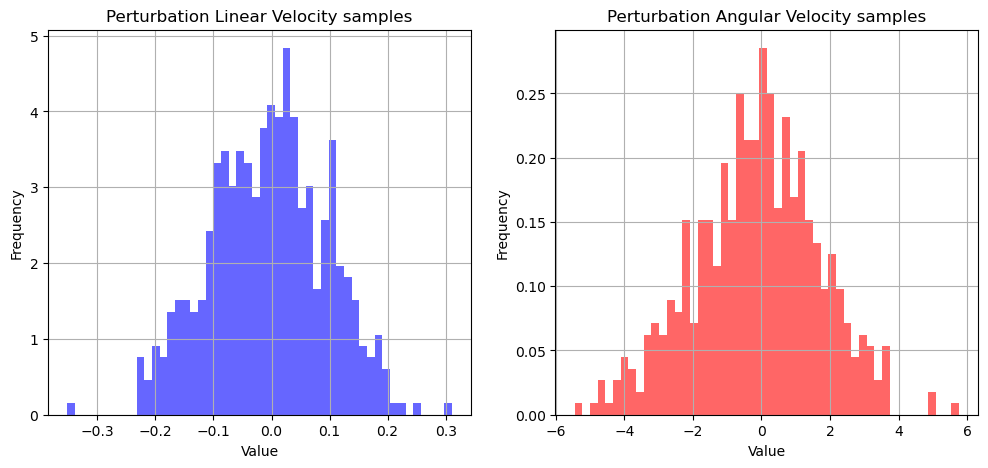

shape of perturbations: (50, 10, 2)


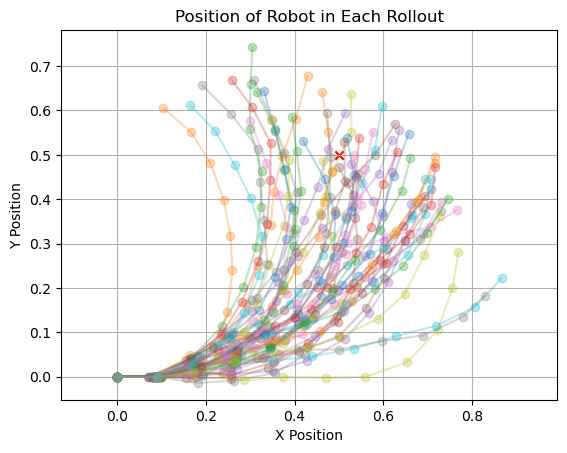

[0.65510962 0.67384974 0.65686734 0.67415797 0.69382821 0.69891495
 0.61944791 0.60912067 0.7026463  0.70167198 0.63437245 0.71744257
 0.66757736 0.6582205  0.65387017 0.63874969 0.64192631 0.67370452
 0.6550909  0.64593767 0.6726292  0.63519639 0.67816234 0.61873608
 0.60604965 0.64995037 0.65361762 0.69172932 0.56610887 0.56847667
 0.67292441 0.61450748 0.61757916 0.65401512 0.68956008 0.61024374
 0.68234127 0.56747266 0.65389222 0.62857016 0.68171216 0.63654792
 0.64704528 0.64177466 0.64731053 0.67532929 0.64728323 0.65498318
 0.60208174 0.63554298]


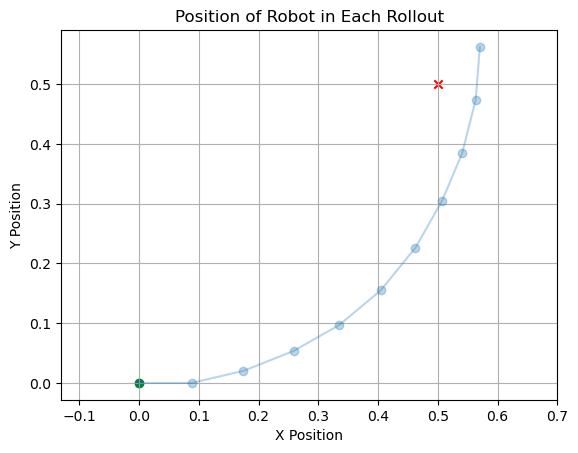

[[0.88342322 2.28909274]
 [0.88715325 1.49446435]
 [0.90264067 1.38354034]
 [0.88026278 1.79327656]
 [0.90202826 1.91191489]
 [0.92175405 1.67814458]
 [0.90214644 1.15716484]
 [0.86573436 1.52868743]
 [0.92144908 1.68743994]
 [0.88549292 1.71667012]]
[[0.9 1.8]
 [0.9 1.8]
 [0.9 1.8]
 [0.9 1.8]
 [0.9 1.8]
 [0.9 1.8]
 [0.9 1.8]
 [0.9 1.8]
 [0.9 1.8]
 [0.9 1.8]]


In [7]:
# Initialize the environment (and set random seed so any randomness is repeatable)
np.random.seed(0)
obs, _ = env.reset()

# Set the starting state (x, y, theta) and goal position (x, y).
initial_state = np.array([0.0, 0.0, 0.0])
goal_pos = np.array([0.5,0.5])

# Instantiate your contoller class
controller = MPPI()

# Run your control algorithm for 1 step. We'll worry about running your
# algorithm in closed-loop in later parts of the assignment.
action = controller.get_action(initial_state, goal_pos)

## 1b) MPPI to drive around a racetrack

Now you will extend your MPPI implementation so that your robot drives around a racetrack. There are a few interesting challenges you'll need to figure out that didn't appear in the earlier problem:

*   How to score rollouts? Some possible ideas include placing waypoints around the track, designing a cost-to-go function, or encouraging the vehicle to maintain full speed, but this is completely up to you!
*   How to ensure the robot doesn't collide with the walls? You can transform coordinates from the world frame to map cell indices using `self.static_map.world_coordinates_to_map_indices(states_in_world)` and `self.static_map.static_map[map_indices]` to check whether a cell of the map is occupied or free.

**Deliverables**:
- Implement the `MPPIRacetrack` class below to enable your robot to complete a full lap around the track
- Generate a plot of the path taken with some indication of time (e.g., using a colorbar, timestamps every so often along the path, or another creative way you come up with)

In [12]:
# Create an instance of the mobile robot simulator we'll use this semester
env = gymnasium.make("gym_neu_racing/NEURacing-v0")

# Tell the simulator to directly provide the current state vector (no sensors yet)
env = StateFeedbackWrapper(env)

In [32]:
class MPPIRacetrack:
    def __init__(
        self,
        static_map,
        motion_model=motion_models.Unicycle(),
        v_min=0, v_max=1, w_min=-2*np.pi, w_max=2*np.pi,
        num_rollouts = 50,
        num_steps = 10,
        lamda = 0.1,
        way_points = [[-2.3,0],[0,4.1],[2.9,2.8],[3.2,0],[0,-1.8]],
        #env = gymnasium.Env                                        <<<<<<<<<<<<<<<<<<<<<<<<
    ):
        """ Your implementation here """
        self.motion_model = motion_model
        self.static_map = static_map
        self.action_space = spaces.Box(np.array([v_min, w_min]),
                                       np.array([v_max, w_max]), shape=(2,), dtype=float)
        self.num_rollouts = num_rollouts
        self.num_steps = num_steps
        self.perturbations = None
        self.lamda = lamda
        self.way_points = way_points
        self.target_way_point = -1
        self.bin_map = self.static_map.static_map.astype(int)
        print(self.bin_map)
        #self.env = env                                             #<<<<<<<<<<<<<<<<<<<<<<<<<

    def generate_perturbations(self):
      '''
      Generates pertubations by randomly sampling form normal distrabution
      i/p : self
      o/p : np.ndarray of shape (self.num_rollouts,self.num_steps,2)
      '''
      V_samples = np.random.normal(0, 0.01, size=(self.num_rollouts, self.num_steps))
      V_scaled_samples = np.clip(V_samples, -1, 1)
      dv = V_scaled_samples
      W_samples = np.random.normal(0, 0.2, size=(self.num_rollouts, self.num_steps))
      W_scaled_samples = np.clip(W_samples, -1, 1)
      dw = W_scaled_samples * 2 * np.pi
      perturbations = []
      for n in range(self.num_rollouts):
        du_N = []
        for t in range(self.num_steps):
          du_N.append([dv[n,t], dw[n,t]])
        perturbations.append(du_N)

      self.perturbations = np.array(perturbations)

      # Plotting histograms of samples
      perturbations = np.array(self.perturbations)
      fig, axes = plt.subplots(1, 2, figsize=(12, 5))
      # Titles for the histograms
      titles = ['Linear Velocity', 'Angular Velocity']
      for i, ax in enumerate(axes):
          ax.hist(perturbations[:, :, i].reshape(-1), bins=50, density=True, alpha=0.6, color='b' if i == 0 else 'r')
          ax.set_title(f'Histogram for {titles[i]} samples')
          ax.set_xlabel('Value')
          ax.set_ylabel('Frequency')
          ax.grid(True)
      plt.show()
      print("shape of perturbations:", np.shape(self.perturbations))

    def open_loop_control_policy(self, init_state: np.ndarray, goal: np.ndarray, num_steps: int = 10) -> list[np.ndarray]:
      # The goal state is in global frame so we need to convert it to robot farame
      initial_x = init_state[0]
      initial_y = init_state[1]
      initial_theta = init_state[2]
      rotation_mat = [[ np.cos(initial_theta), np.sin(initial_theta)] ,
                      [-1 * np.sin(initial_theta), np.cos(initial_theta)]]
      g = goal.tolist()
      dif_initial_g = [g[0] - initial_x, g[1] - initial_y]
      x_relative , y_relative = np.matmul(rotation_mat, dif_initial_g)

      len_squ = (x_relative)**2 + (y_relative)**2

      # lets consider tangential velocity 1m/s
      v = 1
      if y_relative==0:
        w = 0.001
      else:
        r =  len_squ / (2* y_relative)
        w =  v / r
      control_sequence = []
      for i in range(num_steps):
        control_sequence.append(np.array([v,w]))
      return np.array(control_sequence)

    def simulting_action_seq(self, initial_state: np.ndarray, NxT_control_sequences):
      N, T, _ = NxT_control_sequences.shape
      NxTplus1_states = []
      for n in range(N):
        Tplus1_states = []
        state = initial_state
        Tplus1_states.append(state)
        for t in range(T):
          state = self.motion_model.step(state, NxT_control_sequences[n,t])
          Tplus1_states.append(state)
        NxTplus1_states.append(Tplus1_states)
      NxTplus1_states = np.array(NxTplus1_states)
      return NxTplus1_states

    def plot_rollouts(self, initial_state: np.ndarray, goal_pos: np.ndarray, NxTplus1_states, env):
      # Draw a map of the environment with the finish line + initial position
      # Clearing the pevious image
      env =  self.env
      clear_output(wait=True)
      ax = env.unwrapped.map.draw_map(show=False)
      ax.plot(
          env.unwrapped.finish_line[:, 0],
          env.unwrapped.finish_line[:, 1],
          "g",
          lw=3,
      )
      # ax.plot(obs[0], obs[1], "rx")
      # Plotting each rollout
      N, T_plus_1, _ = NxTplus1_states.shape
      for i in range(N):
          rollout = NxTplus1_states[i]
          x_positions = rollout[:, 0]
          y_positions = rollout[:, 1]
          ax.plot(x_positions, y_positions, label=f'Rollout {i+1}', alpha = 0.3)
      ax.scatter(initial_state[0], initial_state[1], color='green', marker='o', label='Initial State')
      ax.scatter(goal_pos[0], goal_pos[1], color='red', marker='x', label='Goal Position')
      # Adding labels and legend
      ax.axis('equal')
      ax.grid(False)
      plt.show()

    def calculate_distance(self,point1, point2):
        x1, y1 = point1
        x2, y2 = point2
        distance = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
        return distance

    def score_rollouts(self,initial_state: np.ndarray, goal_pos: np.ndarray, NxTplus1_states: np.ndarray):
      """
      Cost is calculated by calculating distance between the intermediat states to the goal state
      Returns: Normalized costs of each rollout
      """

      N, T_plus_1, _ = NxTplus1_states.shape
      D = self.calculate_distance(initial_state[:-1], goal_pos) #Distance form initial state to goal
      N_costs = []
      for n in range(N):
        cost = 0
        reached_goal = False
        hit_wall = False
        for t in range(T_plus_1):
          if hit_wall:
            cost += 0
          elif reached_goal:
            cost += 0
          else:
            x = NxTplus1_states[n,t][0]
            y = NxTplus1_states[n,t][1]
            d = self.calculate_distance([x,y], goal_pos)

            map_indices = self.static_map.world_coordinates_to_map_indices(np.array([x, y]))
            row_index, col_index = map_indices[0]
            hit_wall = self.static_map.static_map[row_index, col_index]

            #print("hit_wall :", hit_wall)
            if hit_wall:
              cost += 10000
            elif d<=0.1:
              reached_goal = True
              cost += 0
            else:
              cost += d
        total_cost = cost/(self.num_steps)
        N_costs.append(total_cost)
      N_costs = np.array(N_costs)
      return N_costs

    def extract_segment_from_map(self, robot_x, robot_y, box_size=9):
        """
        Extracts a segment from the map centered around the robot's coordinates.
    
        Parameters:
            bin_map (ndarray): The binary map.
            robot_x (int): The x-coordinate of the robot.
            robot_y (int): The y-coordinate of the robot.
            box_size (int): The size of the bounding box. Default is 9x9.
    
        Returns:
            ndarray: The extracted segment.
        """
        bin_map = self.bin_map
        half_box_size = box_size // 2
    
        # Calculate the bounding box coordinates
        x_min = max(0, robot_x - half_box_size)
        x_max = min(bin_map.shape[0], robot_x + half_box_size + 1)
        y_min = max(0, robot_y - half_box_size)
        y_max = min(bin_map.shape[1], robot_y + half_box_size + 1)
    
        # Extract the segment from the map
        segment = bin_map[x_min:x_max, y_min:y_max]
    
        # If the segment is smaller than the desired size, pad it with 1s
        pad_x = box_size - segment.shape[0]
        pad_y = box_size - segment.shape[1]
        segment_padded = np.pad(segment, ((0, pad_x), (0, pad_y)), mode='constant', constant_values=1)
    
        return segment_padded
        
    def extract_training_data(self, initial_state: np.ndarray, goal_pos: np.ndarray, updated_u_dash, env):
        """Inputs for the network""" 
        # Step 1: Extract M x M box arround the current position of robot 
        
        # 1.1 : extract the map indices of current state
        map_indices_curr = self.static_map.world_coordinates_to_map_indices(initial_state)
        # 1.2 : Extract box arround this state 
        # Initialize a 9x9 array with all elements as 1 (outside the map)
        bounding_box = np.ones((9, 9), dtype=int)
    
        # Calculate the starting and ending indices for the bounding box
        start_x = max(0, map_indices_curr[0] - 4)
        start_y = max(0, map_indices_curr[1] - 4)
        end_x = min(map_size[0] - 1, map_indices_curr[0] + 4)
        end_y = min(map_size[1] - 1, map_indices_curr[1] + 4)
    
        # Calculate the offset to adjust the bounding box indices
        offset_x = 4 - map_indices_curr[0] + start_x
        offset_y = 4 - map_indices_curr[1] + start_y
    
        # Fill the bounding box area with 0s (inside the map)
        bounding_box[offset_x:offset_x + end_x - start_x + 1, offset_y:offset_y + end_y - start_y + 1] = 0
        
        # Step 2: Convert that MxM box to 1D array 
        
        # Step 3: Append the Initial state

        # Step 4: Append Goal State

        # Step 5: Append limits 
        
        """Outputs of the the network """
        # Step 1: Convert the Actions 2D array to 1D array
        
        """ appending the data into csv file """
        


    def get_action(self, initial_state: np.array, env = gymnasium.Env) -> np.array:
        """ Your implementation here """
        env = gymnasium.Env
        ## Step 1 : Creating the random samples of N control perturbations seqences
        if self.perturbations is None:
          self.generate_perturbations()
        ############ Generating Goal from way points #################
        dis_target_wp = self.calculate_distance(initial_state[:-1], self.way_points[self.target_way_point])
        if dis_target_wp <= 1 or self.target_way_point == -1:
          #Updating the target_way_point
          no_of_waypoints = len(self.way_points)
          self.target_way_point +=1
          self.target_way_point = np.mod(self.target_way_point, no_of_waypoints)
        # assigning it as goal
        goal_pos = np.array(self.way_points[self.target_way_point])

        ## Step 2 : Pass control Sequences throught dynamic model
        # 2.1 : Generating primaray control using open loop control
        u_dash = self.open_loop_control_policy(init_state=initial_state, goal = goal_pos, num_steps= self.num_steps)

        # 2.2 : Adding perturbations and creating N control sequences
        NxT_control_sequences = np.copy(self.perturbations)
        for n in range(self.num_rollouts):
          for t in range(self.num_steps):
            NxT_control_sequences[n,t,0] = u_dash[t,0] + NxT_control_sequences[n,t,0]
            NxT_control_sequences[n,t,1] = u_dash[t,1] + NxT_control_sequences[n,t,1]

        # 2.3 : passing throught kinematics model
        """initial_state sequence_of_actions >> kinematics model >> states at each steps """
        NxTplus1_states = self.simulting_action_seq(initial_state, NxT_control_sequences)

        # 2.4 : Plotting Rollouts
        #self.plot_rollouts(initial_state, goal_pos, NxTplus1_states, env)                      #<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<

        ## Step 3 : Scorring Rollouts
        """ states of each rollout at each step >> cost functin >> score of rollout """
        N_costs = self.score_rollouts(initial_state, goal_pos, NxTplus1_states)

        ## Step 4 : Updating weighted sum only for the initial step
        # 4.1 : Calcualting Weights
        exp_costs = np.exp(-1*N_costs/self.lamda)
        sum_exp_costs = np.sum(exp_costs)
        N_weights = exp_costs/sum_exp_costs

        # 4.2 : Updating the initial control sequence
        NxT_perturbations = self.perturbations
        updated_u_dash = np.copy(u_dash)
        for t in range(self.num_steps):
          dv = 0
          dw = 0
          for n in range(self.num_rollouts):
            dv += NxT_perturbations[n,t][0] * N_weights[n]
            dw += NxT_perturbations[n,t][1] * N_weights[n]
          updated_u_dash[t][0] = updated_u_dash[t][0] + dv
          updated_u_dash[t][1] = updated_u_dash[t][1] + dw

        # checking the control limits
        updated_u_dash[:,0] = np.clip(updated_u_dash[:,0], -1, 1)
        updated_u_dash[:,1] = np.clip(updated_u_dash[:,1], -2*np.pi, 2*np.pi)

        # 4.3 Plot the updated trajectory
        # passing through simulatior or kinematics model
        NxTplus1_states = self.simulting_action_seq(initial_state, np.expand_dims(updated_u_dash, axis=0))
        #self.plot_rollouts(initial_state, goal_pos, NxTplus1_states, env)                             #<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
        extract_training_data(self, initial_state: np.ndarray, goal_pos: np.ndarray, updated_u_dash, env)

        return updated_u_dash[0]

[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]


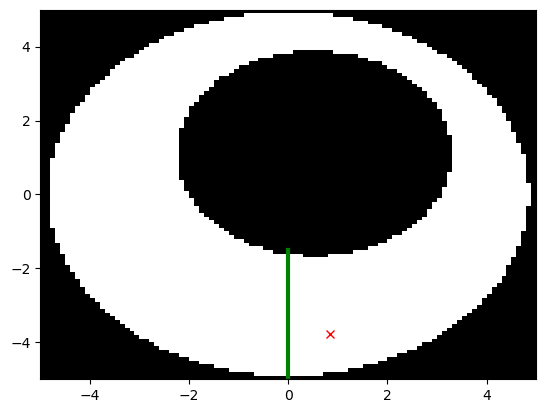

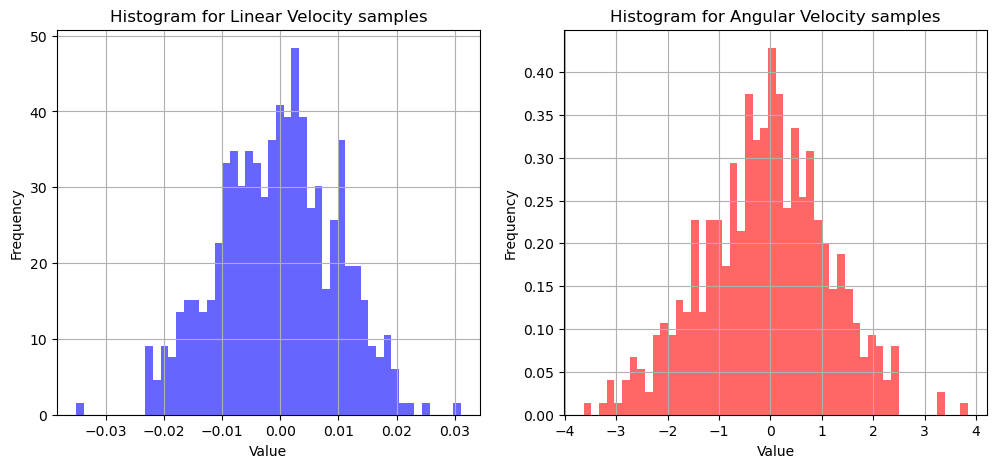

shape of perturbations: (50, 10, 2)
lap completed!
clockwise -> fwd lap completed
lap completed!
clockwise -> fwd lap completed
lap completed!
clockwise -> fwd lap completed


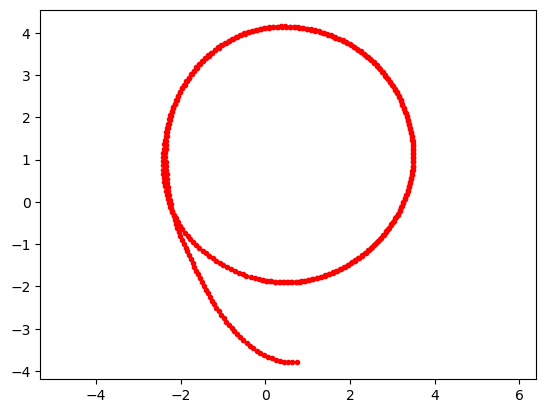

num timesteps used: 397


In [33]:
def run_planner_on_racetrack(
    env: gymnasium.Env,
    planner_class=MPPIRacetrack,
    seed: int = 0,
    num_laps: int = 3,
) -> int:

    np.random.seed(seed)
    obs, _ = env.reset()
    env.unwrapped.laps_left = num_laps

    # Create an instance of your planner
    planner = planner_class(static_map=env.unwrapped.map,
        num_rollouts = 50,  ##????
        num_steps = 10, ##????
        lamda = 0.1)

    # Draw a map of the environment with the finish line + initial position
    ax = env.unwrapped.map.draw_map(show=False)
    ax.plot(
        env.unwrapped.finish_line[:, 0],
        env.unwrapped.finish_line[:, 1],
        "g",
        lw=3,
    )
    ax.plot(obs[0], obs[1], "rx")

    # Run the environment for num_timesteps, unless the robot hits an obstacle
    # or successfully completes the number of laps needed
    num_timesteps = 500
    success = False
    position = []
    for t in range(num_timesteps):
        action = planner.get_action(obs)
        obs, _, terminated, _, _ = env.step(action)

        ax.plot(obs[0], obs[1], "bx")
        position.append([obs[0], obs[1]])
        if terminated:
            success = True
            break

    num_timesteps_used = t
    plt.show()

    for t in range(len(position)):
      plt.scatter(position[t][0], position[t][1],color='red', marker = ".")
    plt.axis('equal')
    plt.show()

    if success:
        return num_timesteps_used
    else:
        return -1



seed = 0
num_laps = 3
planner_class = MPPIRacetrack
num_timesteps_used = run_planner_on_racetrack(
    env, planner_class=planner_class, seed=seed, num_laps=num_laps
)
print(f"num timesteps used: {num_timesteps_used}")

In [21]:
import numpy as np

def extract_square_values(array, center, length, orientation):
    # Convert orientation to radians
    orientation_rad = np.deg2rad(orientation)

    # Get the rotation matrix
    rotation_matrix = np.array([[np.cos(orientation_rad), -np.sin(orientation_rad)],
                                 [np.sin(orientation_rad), np.cos(orientation_rad)]])

    # Calculate the four corner points of the square
    half_length = length / 2
    corner_points = np.array([[-half_length, -half_length],
                              [half_length, -half_length],
                              [half_length, half_length],
                              [-half_length, half_length]])

    # Rotate and translate the corner points to get their absolute positions
    rotated_corner_points = np.dot(corner_points, rotation_matrix.T) + center

    # Round the corner points to get integer indices
    corner_indices = np.round(rotated_corner_points).astype(int)

    # Initialize square values with zeros
    square_values = []

    # Extract values from the original array using the corner indices
    for idx in corner_indices:
        if 0 <= idx[0] < array.shape[0] and 0 <= idx[1] < array.shape[1]:
            square_values.append(array[idx[0], idx[1]])
        else:
            square_values.append(0)  # Add zero-padding for out-of-bounds indices

    return square_values

# Example 2D numpy array
array = np.array([[1, 2, 3, 4, 5],
                  [6, 7, 8, 9, 10],
                  [11, 12, 13, 14, 15],
                  [16, 17, 18, 19, 20],
                  [21, 22, 23, 24, 25]])

# Example parameters for the square
center = np.array([2.5, 2.5])  # Center of the square
length = 3  # Length of sides of the square
orientation = 45  # Orientation of the square in degrees

# Extract values inside the square
square_values = extract_square_values(array, center, length, orientation)
print("Values inside the square:", square_values)


Values inside the square: [11, 0, 0, 3]


## [Extra Credit] 1c) Compete for the fastest lap time

In this part, you can earn extra credit by achieving faster lap times (measured in average number of steps to complete the course, not computational runtime). You can get some extra credit by implementing a working version of something interesting here (e.g., another planning algorithm, a learning-based method, an extension beyond the basic MPPI we discussed in class). We will give additional extra credit to the student with the fastest lap time, which can be monitored on the Gradescope leaderboard.

In [22]:
class BetterPlanner:
    def __init__(
        self,
        static_map,
        motion_model=motion_models.Unicycle(),
        v_min=0, v_max=1, w_min=-2*np.pi, w_max=2*np.pi,
        num_rollouts = 50,
        num_steps = 40,
        lamda = 0.1,
        way_points = [[-2.6,0],[0,4.3],[3,3],[3.5,0],[0,-2]],
        #env = gymnasium.Env                                        <<<<<<<<<<<<<<<<<<<<<<<<
    ):
        """ Your implementation here """
        self.motion_model = motion_model
        self.static_map = static_map
        self.action_space = spaces.Box(np.array([v_min, w_min]),
                                       np.array([v_max, w_max]), shape=(2,), dtype=float)
        self.num_rollouts = num_rollouts
        self.num_steps = num_steps
        self.perturbations = None
        self.lamda = lamda
        self.way_points = way_points
        self.target_way_point = -1
        self.env = env                                             #<<<<<<<<<<<<<<<<<<<<<<<<<

    def generate_perturbations(self):
      '''
      Generates pertubations by randomly sampling form normal distrabution
      i/p : self
      o/p : np.ndarray of shape (self.num_rollouts,self.num_steps,2)
      '''
      V_samples = np.random.normal(0, 0.01, size=(self.num_rollouts, self.num_steps))
      V_scaled_samples = np.clip(V_samples, -1, 1)
      dv = V_scaled_samples
      W_samples = np.random.normal(0, 0.3, size=(self.num_rollouts, self.num_steps))
      W_scaled_samples = np.clip(W_samples, -1, 1)
      dw = W_scaled_samples * 2 * np.pi
      perturbations = []
      for n in range(self.num_rollouts):
        du_N = []
        for t in range(self.num_steps):
          du_N.append([dv[n,t], dw[n,t]])
        perturbations.append(du_N)

      self.perturbations = np.array(perturbations)

      # Plotting histograms of samples
      perturbations = np.array(self.perturbations)
      fig, axes = plt.subplots(1, 2, figsize=(12, 5))
      # Titles for the histograms
      titles = ['Linear Velocity', 'Angular Velocity']
      for i, ax in enumerate(axes):
          ax.hist(perturbations[:, :, i].reshape(-1), bins=50, density=True, alpha=0.6, color='b' if i == 0 else 'r')
          ax.set_title(f'Histogram for {titles[i]} samples')
          ax.set_xlabel('Value')
          ax.set_ylabel('Frequency')
          ax.grid(True)
      plt.show()
      print("shape of perturbations:", np.shape(self.perturbations))

    def open_loop_control_policy(self, init_state: np.ndarray, goal: np.ndarray, num_steps: int = 10) -> list[np.ndarray]:
      # The goal state is in global frame so we need to convert it to robot farame
      initial_x = init_state[0]
      initial_y = init_state[1]
      initial_theta = init_state[2]
      rotation_mat = [[ np.cos(initial_theta), np.sin(initial_theta)] ,
                      [-1 * np.sin(initial_theta), np.cos(initial_theta)]]
      g = goal.tolist()
      dif_initial_g = [g[0] - initial_x, g[1] - initial_y]
      x_relative , y_relative = np.matmul(rotation_mat, dif_initial_g)

      len_squ = (x_relative)**2 + (y_relative)**2

      # lets consider tangential velocity 1m/s
      v = 1
      if y_relative==0:
        w = 0.001
      else:
        r =  len_squ / (2* y_relative)
        w =  v / r
      control_sequence = []
      for i in range(num_steps):
        control_sequence.append(np.array([v,w]))
      return np.array(control_sequence)

    def simulting_action_seq(self, initial_state: np.ndarray, NxT_control_sequences):
      N, T, _ = NxT_control_sequences.shape
      NxTplus1_states = []
      for n in range(N):
        Tplus1_states = []
        state = initial_state
        Tplus1_states.append(state)
        for t in range(T):
          state = self.motion_model.step(state, NxT_control_sequences[n,t])
          Tplus1_states.append(state)
        NxTplus1_states.append(Tplus1_states)
      NxTplus1_states = np.array(NxTplus1_states)
      return NxTplus1_states

    def plot_rollouts(self, initial_state: np.ndarray, goal_pos: np.ndarray, NxTplus1_states, env):
      # Draw a map of the environment with the finish line + initial position
      # Clearing the pevious image
      env =  self.env
      clear_output(wait=True)
      ax = env.unwrapped.map.draw_map(show=False)
      ax.plot(
          env.unwrapped.finish_line[:, 0],
          env.unwrapped.finish_line[:, 1],
          "g",
          lw=3,
      )
      # ax.plot(obs[0], obs[1], "rx")
      # Plotting each rollout
      N, T_plus_1, _ = NxTplus1_states.shape
      for i in range(N):
          rollout = NxTplus1_states[i]
          x_positions = rollout[:, 0]
          y_positions = rollout[:, 1]
          ax.plot(x_positions, y_positions, label=f'Rollout {i+1}', alpha = 0.3)
      ax.scatter(initial_state[0], initial_state[1], color='green', marker='o', label='Initial State')
      ax.scatter(goal_pos[0], goal_pos[1], color='red', marker='x', label='Goal Position')
      # Adding labels and legend
      ax.axis('equal')
      ax.grid(False)
      plt.show()

    def calculate_distance(self,point1, point2):
        x1, y1 = point1
        x2, y2 = point2
        distance = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
        return distance

    def score_rollouts(self,initial_state: np.ndarray, goal_pos: np.ndarray, NxTplus1_states: np.ndarray):
      """
      Cost is calculated by calculating distance between the intermediat states to the goal state
      Returns: Normalized costs of each rollout
      """

      N, T_plus_1, _ = NxTplus1_states.shape
      D = self.calculate_distance(initial_state[:-1], goal_pos) #Distance form initial state to goal
      N_costs = []
      for n in range(N):
        cost = 0
        reached_goal = False
        hit_wall = False
        for t in range(T_plus_1):
          if hit_wall:
            cost += 0
          elif reached_goal:
            cost += 0
          else:
            x = NxTplus1_states[n,t][0]
            y = NxTplus1_states[n,t][1]
            d = self.calculate_distance([x,y], goal_pos)

            map_indices = self.static_map.world_coordinates_to_map_indices(np.array([x, y]))
            row_index, col_index = map_indices[0]
            hit_wall = self.static_map.static_map[row_index, col_index]

            #print("hit_wall :", hit_wall)
            if hit_wall:
              cost += 10000
            elif d<=0.1:
              reached_goal = True
              cost += 0
            else:
              cost += d
        total_cost = cost/(self.num_steps)
        N_costs.append(total_cost)
      N_costs = np.array(N_costs)
      return N_costs

    def get_action(self, initial_state: np.array, env = gymnasium.Env) -> np.array:
        """ Your implementation here """
        env = gymnasium.Env
        ## Step 1 : Creating the random samples of N control perturbations seqences
        if self.perturbations is None:
          self.generate_perturbations()
        ############ Generating Goal from way points #################
        dis_target_wp = self.calculate_distance(initial_state[:-1], self.way_points[self.target_way_point])
        if dis_target_wp <= 1 or self.target_way_point == -1:
          #Updating the target_way_point
          no_of_waypoints = len(self.way_points)
          self.target_way_point +=1
          self.target_way_point = np.mod(self.target_way_point, no_of_waypoints)
        # assigning it as goal
        goal_pos = np.array(self.way_points[self.target_way_point])

        ## Step 2 : Pass control Sequences throught dynamic model
        # 2.1 : Generating primaray control using open loop control
        u_dash = self.open_loop_control_policy(init_state=initial_state, goal = goal_pos, num_steps= self.num_steps)

        # 2.2 : Adding perturbations and creating N control sequences
        NxT_control_sequences = np.copy(self.perturbations)
        for n in range(self.num_rollouts):
          for t in range(self.num_steps):
            NxT_control_sequences[n,t,0] = u_dash[t,0] + NxT_control_sequences[n,t,0]
            NxT_control_sequences[n,t,1] = u_dash[t,1] + NxT_control_sequences[n,t,1]

        # 2.3 : passing throught kinematics model
        """initial_state sequence_of_actions >> kinematics model >> states at each steps """
        NxTplus1_states = self.simulting_action_seq(initial_state, NxT_control_sequences)

        # 2.4 : Plotting Rollouts
        self.plot_rollouts(initial_state, goal_pos, NxTplus1_states, env)                      #<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<

        ## Step 3 : Scorring Rollouts
        """ states of each rollout at each step >> cost functin >> score of rollout """
        N_costs = self.score_rollouts(initial_state, goal_pos, NxTplus1_states)

        ## Step 4 : Updating weighted sum only for the initial step
        # 4.1 : Calcualting Weights
        exp_costs = np.exp(-1*N_costs/self.lamda)
        sum_exp_costs = np.sum(exp_costs)
        N_weights = exp_costs/sum_exp_costs

        # 4.2 : Updating the initial control sequence
        NxT_perturbations = self.perturbations
        updated_u_dash = np.copy(u_dash)
        for t in range(self.num_steps):
          dv = 0
          dw = 0
          for n in range(self.num_rollouts):
            dv += NxT_perturbations[n,t][0] * N_weights[n]
            dw += NxT_perturbations[n,t][1] * N_weights[n]
          updated_u_dash[t][0] = updated_u_dash[t][0] + dv
          updated_u_dash[t][1] = updated_u_dash[t][1] + dw

        # checking the control limits
        updated_u_dash[:,0] = np.clip(updated_u_dash[:,0], -1, 1)
        updated_u_dash[:,1] = np.clip(updated_u_dash[:,1], -2*np.pi, 2*np.pi)

        # 4.3 Plot the updated trajectory
        # passing through simulatior or kinematics model
        NxTplus1_states = self.simulting_action_seq(initial_state, np.expand_dims(updated_u_dash, axis=0))
        self.plot_rollouts(initial_state, goal_pos, NxTplus1_states, env)                             #<<<<<<<<<<<<<<<<<<<<<<<<<<<<<

        return updated_u_dash[0]

In [ ]:
seed = 3
num_laps = 3
planner_class = BetterPlanner
run_planner_on_racetrack(env, planner_class=planner_class, seed=seed, num_laps=num_laps)